In [1]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from data.datasets import get_dataloader
from data.classes import CLASS_MAPPING
from models.models import PoseGRU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# Data loaders
train_loader = get_dataloader("data/split/train.npz", batch_size=32, shuffle=True)
val_loader = get_dataloader("data/split/val.npz", batch_size=32, shuffle=False)
test_loader = get_dataloader("data/split/test.npz", batch_size=32, shuffle=False)

# Loggign batch size
X_batch, y_batch = next(iter(train_loader))
print("Batch X:", X_batch.shape)
print("Batch y:", y_batch.shape)

Batch X: torch.Size([32, 15, 102])
Batch y: torch.Size([32])


In [3]:
# Model
input_dim = X_batch.shape[2]  
num_classes = len(CLASS_MAPPING)

model = PoseGRU(input_dim=input_dim, num_classes=num_classes)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [4]:
# Training
num_epochs = 20
train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---- Validation ----
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
    
    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/20, Train Loss: 2.2923, Val Loss: 1.9570, Val Acc: 0.3037
Epoch 2/20, Train Loss: 1.5615, Val Loss: 1.3060, Val Acc: 0.5314
Epoch 3/20, Train Loss: 1.0246, Val Loss: 0.9795, Val Acc: 0.6440
Epoch 4/20, Train Loss: 0.7587, Val Loss: 0.8864, Val Acc: 0.6859
Epoch 5/20, Train Loss: 0.5884, Val Loss: 0.5982, Val Acc: 0.7827
Epoch 6/20, Train Loss: 0.4573, Val Loss: 0.5458, Val Acc: 0.7853
Epoch 7/20, Train Loss: 0.3435, Val Loss: 0.4632, Val Acc: 0.8403
Epoch 8/20, Train Loss: 0.2887, Val Loss: 0.5022, Val Acc: 0.8246
Epoch 9/20, Train Loss: 0.2559, Val Loss: 0.3523, Val Acc: 0.8639
Epoch 10/20, Train Loss: 0.1761, Val Loss: 0.3301, Val Acc: 0.8979
Epoch 11/20, Train Loss: 0.1667, Val Loss: 0.3374, Val Acc: 0.8901
Epoch 12/20, Train Loss: 0.1451, Val Loss: 0.3283, Val Acc: 0.9084
Epoch 13/20, Train Loss: 0.1758, Val Loss: 0.3240, Val Acc: 0.8979
Epoch 14/20, Train Loss: 0.1154, Val Loss: 0.1791, Val Acc: 0.9398
Epoch 15/20, Train Loss: 0.0490, Val Loss: 0.1983, Val Acc: 0.9424
Epoc

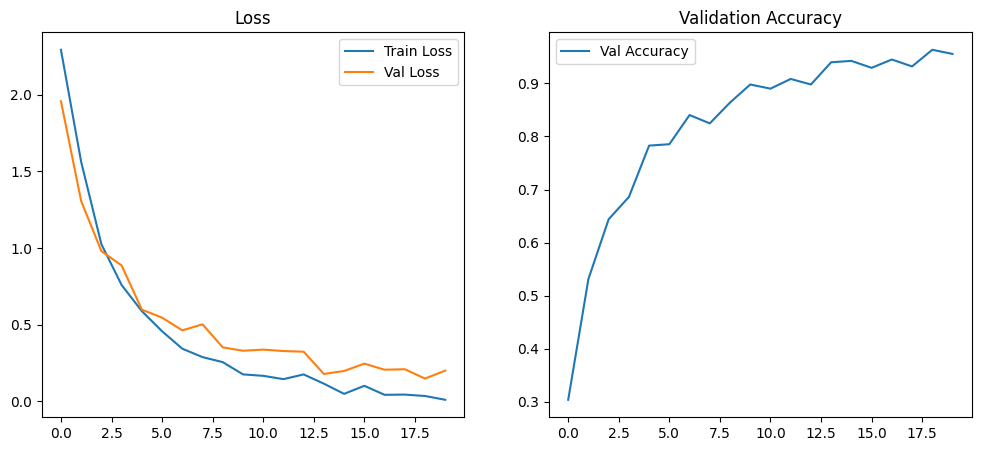

In [5]:
# Learning curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(val_accuracies, label="Val Accuracy")
plt.legend()
plt.title("Validation Accuracy")
plt.show()

Test Accuracy: 0.9608355091383812


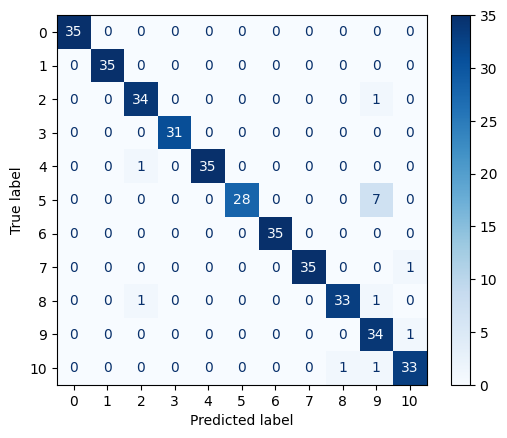

In [6]:
# Test 
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print("Test Accuracy:", acc)

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [ ]:
# Save model
torch.save(model.state_dict(), "trained_models/pose_gru_11class.pt")
print("Saved in trained_models")

Saved in trained_models
